# Hospital Data Analysis

This notebook analyzes hospital patient data using Python.

In [ ]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#load and display the dataset 
df = pd.read_csv("hospital_data.csv")
df

,patient_id,age,gender,disease,doctor,treatment_cost
0,1,8,Female,Fever,Dr Patil,1957
1,2,18,Male,Heart Disease,Dr Joshi,21912
2,3,8,Male,Diabetes,Dr Patil,4952
3,4,8,Male,Dengue,Dr Joshi,7436
4,5,62,Female,Flu,Dr Shah,1326
...,...,...,...,...,...,...
145,146,49,Female,Dengue,Dr Joshi,6709
146,147,63,Female,Asthma,Dr Kulkarni,3529
147,148,20,Male,Flu,Dr Kulkarni,1244
148,149,28,Male,Dengue,Dr Patil,7966


In [ ]:
#display the first few rows of the dataset
df.head()

,patient_id,age,gender,disease,doctor,treatment_cost
0,1,8,Female,Fever,Dr Patil,1957
1,2,18,Male,Heart Disease,Dr Joshi,21912
2,3,8,Male,Diabetes,Dr Patil,4952
3,4,8,Male,Dengue,Dr Joshi,7436
4,5,62,Female,Flu,Dr Shah,1326


In [ ]:
#check dataset structure and summary statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      150 non-null    int64 
 1   age             150 non-null    int64 
 2   gender          150 non-null    object
 3   disease         150 non-null    object
 4   doctor          150 non-null    object
 5   treatment_cost  150 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 7.2+ KB


,patient_id,age,treatment_cost
count,150.000000,150.00000,150.000000
mean,75.500000,42.94000,5297.513333
std,43.445368,21.01461,4819.993395
min,1.000000,5.00000,1003.000000
25%,38.250000,25.25000,2786.000000
50%,75.500000,43.00000,4053.500000
75%,112.750000,59.00000,5849.750000
max,150.000000,80.00000,29327.000000


In [ ]:
#create a new column categorising treatment costs
def categorise_cost(cost):
    if cost < 3000:
        return 'Low'
    elif cost < 8000:
        return 'Medium'
    else:
        return 'High'

df['cost_category'] = df['treatment_cost'].apply(categorise_cost)
df.head()

,patient_id,age,gender,disease,doctor,treatment_cost,cost_category
0,1,8,Female,Fever,Dr Patil,1957,Low
1,2,18,Male,Heart Disease,Dr Joshi,21912,High
2,3,8,Male,Diabetes,Dr Patil,4952,Medium
3,4,8,Male,Dengue,Dr Joshi,7436,Medium
4,5,62,Female,Flu,Dr Shah,1326,Low


In [ ]:
#calculate the total revenue generated from treatments
df['treatment_cost'].sum()

np.int64(794627)

In [ ]:
#count the number of patients for each disease
df['disease'].value_counts()

disease
Flu              20
Dengue           20
Hypertension     19
Malaria          18
Fever            17
Diabetes         13
Pneumonia        12
Asthma           12
Typhoid          11
Heart Disease     8
Name: count, dtype: int64

In [ ]:
#identify most common diseases treated in the hospital
disease_counts = df['disease'].value_counts()

most_common_disease = disease_counts.idxmax()
most_common_count = disease_counts.max()

most_common_disease, most_common_count

('Flu', 20)

In [ ]:
#doctor wise analysis
df.groupby('doctor').agg({
    'patient_id': 'count',
    'treatment_cost': ['sum', 'mean']
})

patient_id treatment_cost             
                 count            sum         mean
doctor                                            
Dr Joshi            24         167384  6974.333333
Dr Kulkarni         25         111179  4447.160000
Dr Mehta            30         139062  4635.400000
Dr Patil            40         247959  6198.975000
Dr Shah             31         129043  4162.677419

In [ ]:
#summary statistics for treatment costs
df.describe()

,patient_id,age,treatment_cost
count,150.000000,150.00000,150.000000
mean,75.500000,42.94000,5297.513333
std,43.445368,21.01461,4819.993395
min,1.000000,5.00000,1003.000000
25%,38.250000,25.25000,2786.000000
50%,75.500000,43.00000,4053.500000
75%,112.750000,59.00000,5849.750000
max,150.000000,80.00000,29327.000000


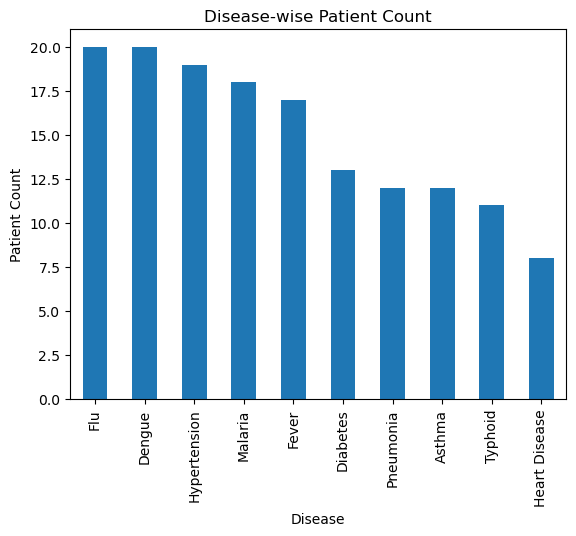

In [ ]:
#disease-wise patient count - bar chart
df['disease'].value_counts().plot(kind='bar')
plt.title("Disease-wise Patient Count")
plt.xlabel("Disease")
plt.ylabel("Patient Count") 
plt.show()

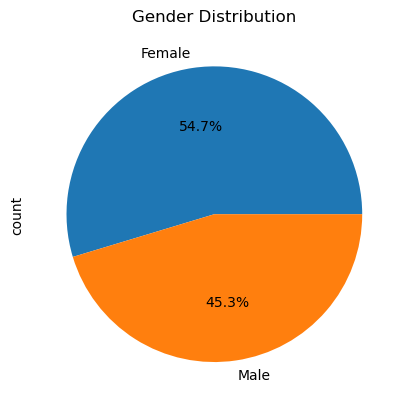

In [ ]:
#gender distribution - pie chart
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

In [ ]:
#gender-wise analysis
df.groupby('gender').agg({
    'patient_id': 'count',
    'treatment_cost': ['mean', 'sum']
})

patient_id treatment_cost        
            count           mean     sum
gender                                  
Female         82    5067.390244  415526
Male           68    5575.014706  379101

In [ ]:
#age group analysis
df['age_group'] = pd.cut(df['age'],
                        bins=[0,17,59,120],
                        labels=['Child','Adult','Senior'])

df.groupby('age_group')['treatment_cost'].agg(['count','mean','sum'])

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_39268\2130950464.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['treatment_cost'].agg(['count','mean','sum'])


,count,mean,sum
age_group,,,
Child,20,4831.600000,96632
Adult,93,5466.774194,508410
Senior,37,5123.918919,189585
